<a href="https://colab.research.google.com/github/Faezeh-Maleki/sentiment-analysis/blob/main/sentiment_analysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Logistic Regression Classification Report:
              precision    recall  f1-score   support

    Negative       0.74      0.67      0.70      7937
     Neutral       0.46      0.18      0.26      4895
    Positive       0.89      0.97      0.93     41979

    accuracy                           0.85     54811
   macro avg       0.70      0.61      0.63     54811
weighted avg       0.83      0.85      0.83     54811

Logistic Regression Accuracy Score: 0.8542993194796665


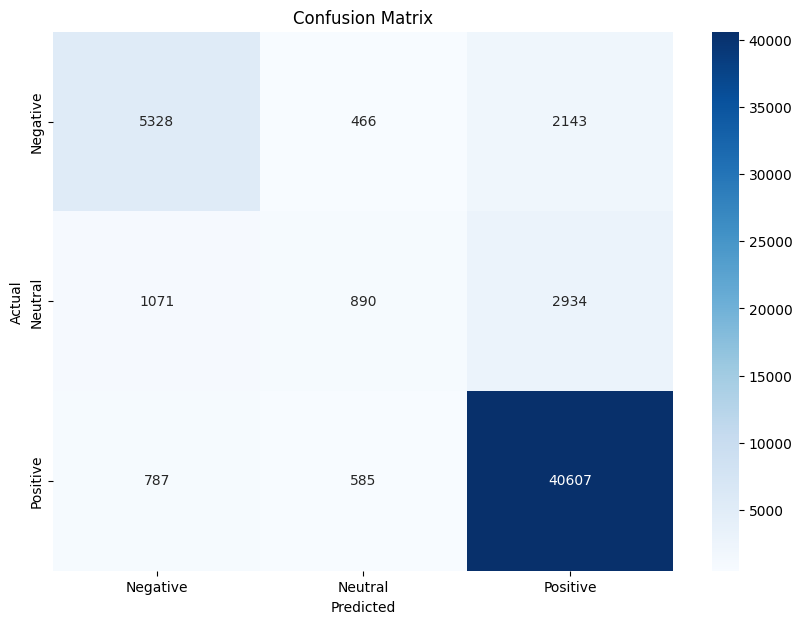

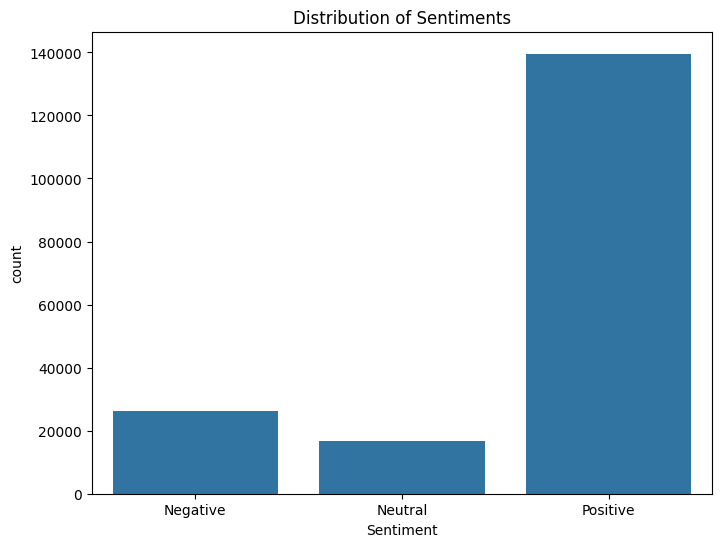

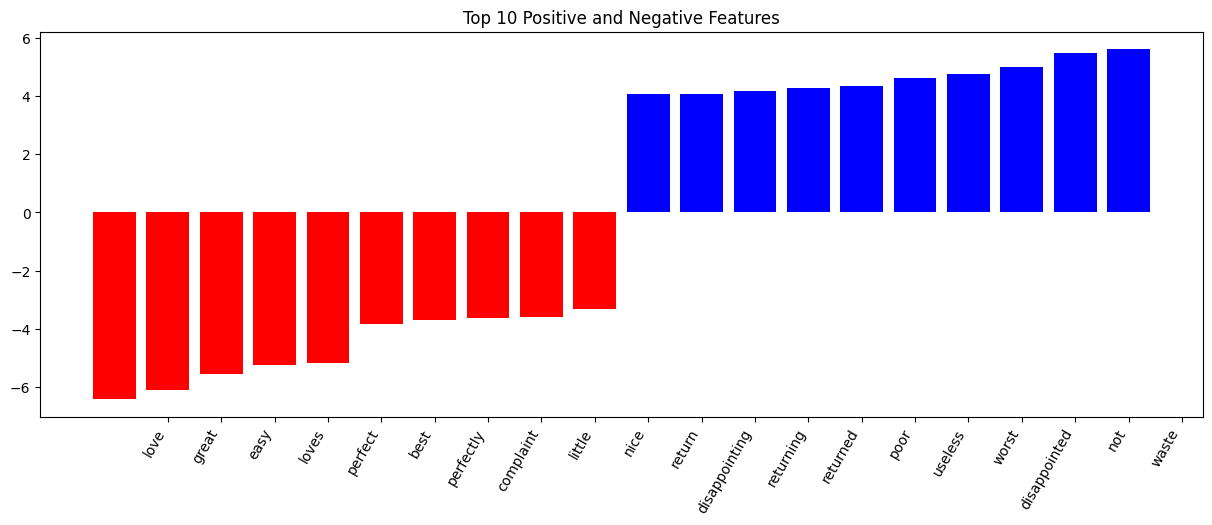

In [4]:
!pip install google-colab
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Load data
file_path = '/content/drive/MyDrive/amazon_baby.csv'
df = pd.read_csv(file_path)

# Remove rows with missing values in the 'review' column
df.dropna(subset=['review'], inplace=True)

# Convert reviews to lowercase and remove non-alphabetic characters
df['review_clean'] = df['review'].apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x.lower()))

# Define sentiment labels based on ratings
def classify_sentiment(rating):
    if rating in [4, 5]:
        return 'Positive'
    elif rating in [1, 2]:
        return 'Negative'
    elif rating == 3:
        return 'Neutral'

df['Sentiment'] = df['rating'].apply(classify_sentiment)

# Initialize the Tfidf Vectorizer to convert text data into numerical features
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['review_clean'])

# Prepare features and labels
X_train, X_test, y_train, y_test = train_test_split(X, df['Sentiment'], test_size=0.3, random_state=42)

# Train a Logistic Regression model
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Print classification report and accuracy score
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred))
print("Logistic Regression Accuracy Score:", accuracy_score(y_test, y_pred))

# Plot confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred, labels=['Negative', 'Neutral', 'Positive'])
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Plot distribution of sentiments
plt.figure(figsize=(8, 6))
sns.countplot(x='Sentiment', data=df, order=['Negative', 'Neutral', 'Positive'])
plt.title('Distribution of Sentiments')
plt.show()

# Plot feature importance
feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]
top_positive_coefficients = np.argsort(coefficients)[-10:]
top_negative_coefficients = np.argsort(coefficients)[:10]
top_coefficients = np.hstack([top_negative_coefficients, top_positive_coefficients])

plt.figure(figsize=(15, 5))
colors = ['red' if c < 0 else 'blue' for c in coefficients[top_coefficients]]
plt.bar(np.arange(2 * 10), coefficients[top_coefficients], color=colors)
feature_names = np.array(feature_names)
plt.xticks(np.arange(1, 1 + 2 * 10), feature_names[top_coefficients], rotation=60, ha='right')
plt.title('Top 10 Positive and Negative Features')
plt.show()